 (Accuracy): 0.4246

 (Classification Report):
               precision    recall  f1-score   support

       Fridge       0.21      0.40      0.28       493
  GPS_Tracker       0.82      0.59      0.68      1262
  Garage_Door       0.84      0.34      0.48       953
Modbus_Sensor       0.18      0.36      0.24       500
   Thermostat       0.30      0.29      0.29       586

     accuracy                           0.42      3794
    macro avg       0.47      0.40      0.40      3794
 weighted avg       0.58      0.42      0.46      3794



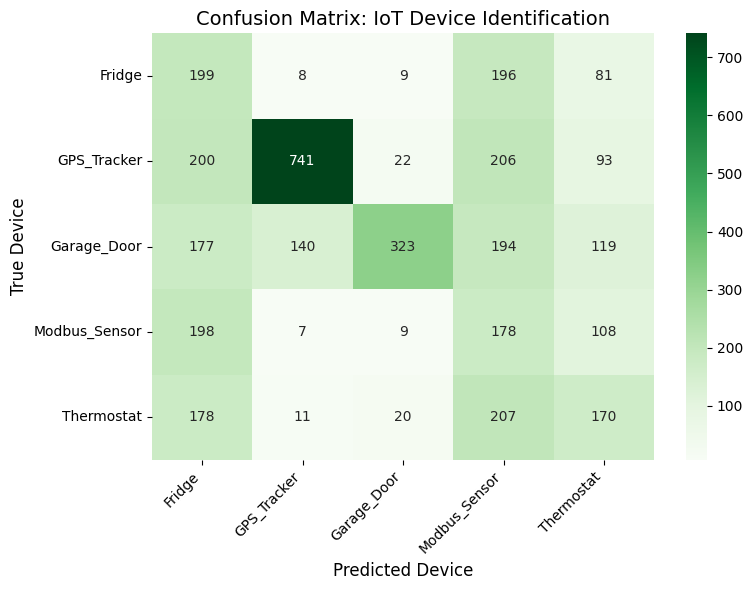

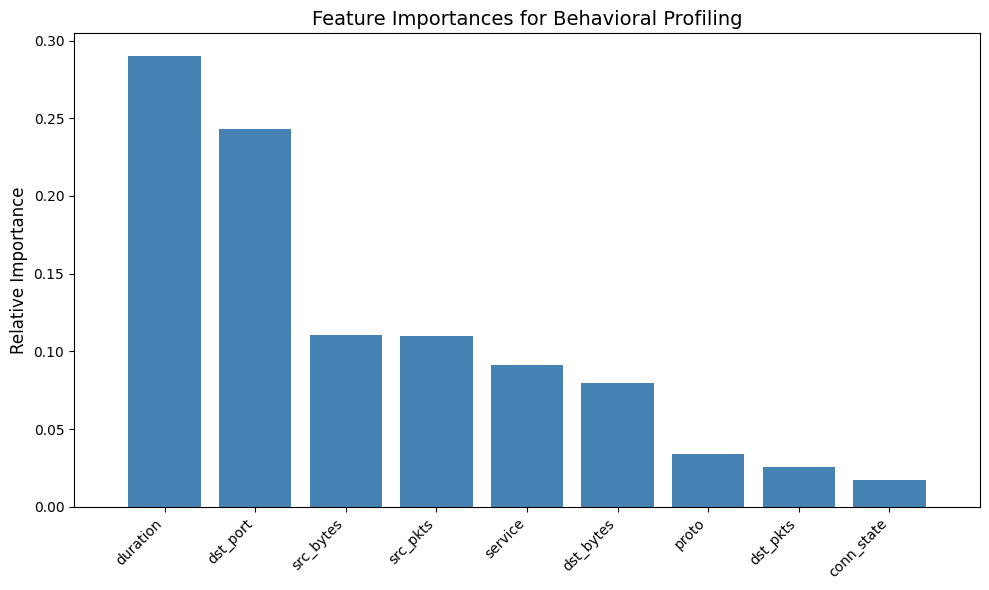

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('train_test_network.csv')


normal_df = df[df['label'] == 0].copy()

iot_devices = {
    '192.168.1.195': 'GPS_Tracker',
    '192.168.1.190': 'Garage_Door',
    '192.168.1.193': 'Thermostat',
    '192.168.1.194': 'Modbus_Sensor',
    '192.168.1.184': 'Fridge'
}


filtered_df = normal_df[normal_df['src_ip'].isin(iot_devices.keys())].copy()
filtered_df['device_type'] = filtered_df['src_ip'].map(iot_devices)


features = [
    'duration',      # 通信持续时间
    'src_bytes',     # 上行字节数
    'dst_bytes',     # 下行字节数
    'src_pkts',      # 上行包数
    'dst_pkts',      # 下行包数
    'dst_port',      # 访问的目的端口 (论文指出 IoT 设备通常只访问特定端口)
    'proto',         # 传输层协议 (TCP/UDP/ICMP)
    'service',       # 应用层服务 (DNS, HTTP, SSL 等信令模式)
    'conn_state'     # 连接状态
]

X = filtered_df[features].copy()
y = filtered_df['device_type']

X['duration'] = pd.to_numeric(X['duration'].replace('-', '0'), errors='coerce').fillna(0)
X['dst_port'] = pd.to_numeric(X['dst_port'].replace('-', '0'), errors='coerce').fillna(0)

label_encoders = {}
categorical_cols = ['proto', 'service', 'conn_state']
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)



y_pred = rf_model.predict(X_test)

print("="*55)
print(f" (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("="*55)
print("\n (Classification Report):")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix: IoT Device Identification', fontsize=14)
plt.ylabel('True Device', fontsize=12)
plt.xlabel('Predicted Device', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [X.columns[i] for i in indices]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances for Behavioral Profiling", fontsize=14)
plt.bar(range(X.shape[1]), importances[indices], align="center", color='steelblue')
plt.xticks(range(X.shape[1]), sorted_features, rotation=45, ha='right')
plt.xlim([-1, X.shape[1]])
plt.ylabel("Relative Importance", fontsize=12)
plt.tight_layout()
plt.show()

# 新段落